In [1]:
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science', 'nature', 'grid'])

import numpy as np
import pandas as pd

from LoadTSV import *

In [2]:
WIDTH = 9.0#!6.0 
HEIGHT = 5.0

plt.rcParams.update({
    "figure.figsize": (WIDTH, HEIGHT),
    "font.size": 10,           # Matches thesis 10pt
    "axes.labelsize": 10,
    "legend.fontsize": 8,      # Slightly smaller for legends
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1,
    "lines.markersize": 4,
    "savefig.bbox": 'tight',   # Ensures no labels are cut off
    "savefig.pad_inches": 0.05
})

In [3]:
# For Comparison
T_end = 0.3
base_tree_level = 10
polydeg = 1
Kn = 0.1
source = "relaxation_source"

# Initial condition parameters for the Riemann problem
rho_L = 7.0
v_L = 0.0
theta_L = 1.0
rho_R = 1.0
v_R = 0.0
theta_R = 1.0

x_lower = -2.0
x_upper = 2.0

# BGK
N = 1_000 # BGK
base_tree_level_bgk = 8
x_left_BGK = -5.0
x_right_BGK = 5.0
c_L = -6.0
c_R = 6.0

# Analytical

### M = 4

In [4]:
from sympy import *
u0, u1, u2, u3, u4, u5 = symbols('u0 u1 u2 u3 u4 u5')
c = symbols('c')
init_printing(use_unicode=True)

In [5]:
M = 4
n = int(M/2)

## Gramian

Latex expression of characteristic polynomial: \frac{\left(c^{2} \left(- u_{0} u_{2} + u_{1}^{2}\right) - u_{2} \left(c u_{1} - u_{2}\right) + u_{3} \left(c u_{0} - u_{1}\right)\right) \left(c^{3} \left(- u_{0} u_{2} + u_{1}^{2}\right) - u_{3} \left(c u_{1} - u_{2}\right) + u_{4} \left(c u_{0} - u_{1}\right)\right)}{\left(u_{0} u_{2} - u_{1}^{2}\right)^{2}}


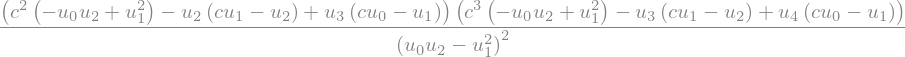

In [6]:
P_Gramian = lambda c: (
    c**2 - Matrix(Matrix([1, c]).T * Matrix([[u0, u1], [u1, u2]]).inv() * Matrix([u2, u3]))[0]     # p_n(c)
) * (
    c**3 - Matrix(Matrix([1, c]).T * Matrix([[u0, u1], [u1, u2]]).inv() * Matrix([u3, u4]))[0]  # p_np(c) -> equation 42
)
P_GramianEven = simplify(P_Gramian(c))

print(f'Latex expression of characteristic polynomial: {latex(P_GramianEven)}')
P_GramianEven

In [7]:
#! We don't want to use this, it seems to add imaginary parts due to numerical errors

# # Roots of P give the eigenvalues of DF
# roots = solve(Eq(P, 0), c)
# roots = [simplify(root) for root in roots]
# print(f'Latex expression of roots: {latex(roots)}')
# roots

In [8]:
# Get numerical eigenvalues at x=-2.0 (equilibrium)

closure = "Gram"
source = "relaxation_source"
file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

x, u, _ = sol_final(file)

file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_eigenvalues.csv"
df = pd.read_csv(file)


x_dest = -2.0
x_idx = (np.abs(df['x_vector'] - x_dest)).argmin()
eigenvalue_string = df['eigenvalue'][x_idx]
eigenvalues_test_equilibrium = [float(val) for val in eigenvalue_string.strip('[]').split(',')]

In [9]:
moments_test_equilibrium = [
    7.0, 
    0.0, 
    7.0, 
    0.0, 
    21.0
]

subs_dict_equilibrium = {
    u0: moments_test_equilibrium[0],
    u1: moments_test_equilibrium[1],
    u2: moments_test_equilibrium[2],
    u3: moments_test_equilibrium[3],
    u4: moments_test_equilibrium[4]
}

P_GramianEven_subs = simplify(P_GramianEven.subs(subs_dict_equilibrium))

roots = solve(Eq(P_GramianEven_subs, 0), c)
roots_subs = [simplify(root) for root in roots]

# Sort eigenvalues for easier comparison
# First assert that maximum imaginary eigenvalue part is small
max_imag_rouots = max([abs(re(root.subs(subs_dict_equilibrium).evalf().as_real_imag()[1])) for root in roots])
assert max_imag_rouots < 1e-10, f"Maximum imaginary part of eigenvalues is too large: {max_imag_rouots}"
roots_subs = [root.subs(subs_dict_equilibrium).evalf().as_real_imag()[0] for root in roots]
roots_subs.sort()
eigenvalues_test_equilibrium.sort()

print("Sorted Computed Eigenvalues:", roots_subs)
print("Sorted Test Eigenvalues:", eigenvalues_test_equilibrium)
# Check if computed eigenvalues match test eigenvalues
err_rel, err_abs = [], []
for r_computed, r_test in zip(roots_subs, eigenvalues_test_equilibrium):
    err_rel.append(abs(r_computed - r_test) / abs(r_test))
    err_abs.append(abs(r_computed - r_test))
print("Relative Errors:", err_rel)
print("Absolute Errors:", err_abs)

Sorted Computed Eigenvalues: [-1.73205080756888, -1.00000000000000, 0, 1.00000000000000, 1.73205080756888]
Sorted Test Eigenvalues: [-1.7320508075688705, -1.0000000000000153, 4.9352447204588605e-19, 1.000000000000016, 1.732050807568869]
Relative Errors: [3.84592537276714e-15, 1.53210777398269e-14, 1.00000000000000, 1.59872115546020e-14, 4.74330795974615e-15]
Absolute Errors: [6.66133814775094e-15, 1.53210777398272e-14, 4.93524472045886e-19, 1.59872115546023e-14, 8.21565038222616e-15]


In [10]:
# Get numerical eigenvalues at x=0.0 (equilibrium)
x_dest = 0.0
x_idx = (np.abs(df['x_vector'] - x_dest)).argmin()
eigenvalue_string = df['eigenvalue'][x_idx]
eigenvalues_test = [float(val) for val in eigenvalue_string.strip('[]').split(',')]
moments_string = df['moments'][x_idx]
moments_test = [float(val) for val in moments_string.strip('[]').split(',')]

In [11]:
subs_dict = {
    u0: moments_test[0],
    u1: moments_test[1],
    u2: moments_test[2],
    u3: moments_test[3],
    u4: moments_test[4]
}

P_GramianEven_subs = simplify(P_GramianEven.subs(subs_dict))

roots = solve(Eq(P_GramianEven_subs, 0), c)
roots_subs = [simplify(root) for root in roots]

# Sort eigenvalues for easier comparison
# First assert that maximum imaginary eigenvalue part is small
max_imag_rouots = max([abs(re(root.subs(subs_dict).evalf().as_real_imag()[1])) for root in roots])
assert max_imag_rouots < 1e-10, f"Maximum imaginary part of eigenvalues is too large: {max_imag_rouots}"
roots_subs = [root.subs(subs_dict).evalf().as_real_imag()[0] for root in roots]
roots_subs.sort()
eigenvalues_test.sort()

print("Sorted Computed Eigenvalues:", roots_subs)
print("Sorted Test Eigenvalues:", eigenvalues_test)
# Check if computed eigenvalues match test eigenvalues
err_rel, err_abs = [], []
for r_computed, r_test in zip(roots_subs, eigenvalues_test):
    err_rel.append(abs(r_computed - r_test) / abs(r_test))
    err_abs.append(abs(r_computed - r_test))
print("Relative Errors:", err_rel)
print("Absolute Errors:", err_abs)

Sorted Computed Eigenvalues: [-1.84143322521312, -0.317476897646015, 0.240036282046595, 1.26419148744351, 1.60139694316653]
Sorted Test Eigenvalues: [-1.841433023828147, -0.317476815059528, 0.24003642127933167, 1.2641892148640725, 1.6013987921336057]
Relative Errors: [1.09363181151880e-7, 2.60133916725676e-7, 5.80048376563085e-7, 1.79765766910585e-6, 1.15459502618194e-6]
Absolute Errors: [2.01384973363972e-7, 8.25864873710280e-8, 1.39232736479089e-7, 2.27257943730130e-6, 1.84896708033122e-6]


## Extended Gramian

In [12]:
chi = (n+1) / n

In [13]:
p_nm = lambda c: c**1 - Matrix(Matrix([1]).T * Matrix([u0]).inv() * Matrix([u1]))[0]
p_n = lambda c: c**2 - Matrix(Matrix([1, c]).T * Matrix([[u0, u1], [u1, u2]]).inv() * Matrix([u2, u3]))[0]
p_np = lambda c: c**3 - Matrix(Matrix([1, c]).T * Matrix([[u0, u1], [u1, u2]]).inv() * Matrix([u3, u4]))[0]  # p_np(c) -> equation 42

sigma_nn = Matrix([u4])[0] - Matrix(Matrix([u2, u3]).T * Matrix([[u0, u1],[u1, u2]]).inv() * Matrix([u2, u3]))[0]
sigma_nmnm = u2 - u1 * u1 / u0

Latex expression of characteristic polynomial: \frac{\left(c^{2} \left(- u_{0} u_{2} + u_{1}^{2}\right) - u_{2} \left(c u_{1} - u_{2}\right) + u_{3} \left(c u_{0} - u_{1}\right)\right) \left(- c^{3} \left(u_{0} u_{2} - u_{1}^{2}\right)^{2} - 1.5 \left(c u_{0} - u_{1}\right) \left(u_{2} \left(- u_{1} u_{3} + u_{2}^{2}\right) + u_{3} \left(u_{0} u_{3} - u_{1} u_{2}\right) - u_{4} \left(u_{0} u_{2} - u_{1}^{2}\right)\right) + \left(u_{0} u_{2} - u_{1}^{2}\right) \left(- u_{3} \left(c u_{1} - u_{2}\right) + u_{4} \left(c u_{0} - u_{1}\right)\right)\right)}{\left(u_{0} u_{2} - u_{1}^{2}\right)^{3}}


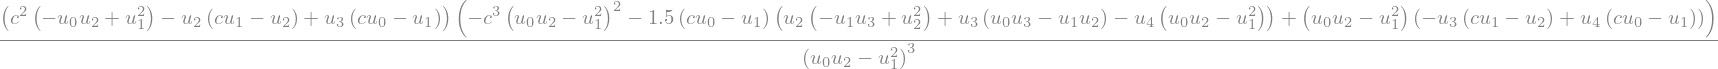

In [14]:
P_ExtendedGramian = lambda c: p_n(c) * (p_np(c) - chi * sigma_nn / sigma_nmnm * p_nm(c)) 
P_ExtendedGramianEven = simplify(P_ExtendedGramian(c))

print(f'Latex expression of characteristic polynomial: {latex(P_ExtendedGramianEven)}')
P_ExtendedGramianEven

In [15]:
# Get numerical eigenvalues at x=-2.0 (equilibrium)
closure = "ExtGram"
file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

x, u, _ = sol_final(file)

file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_eigenvalues.csv"
df = pd.read_csv(file)


x_dest = -2.0
x_idx = (np.abs(df['x_vector'] - x_dest)).argmin()
eigenvalue_string = df['eigenvalue'][x_idx]
eigenvalues_test_equilibrium = [float(val) for val in eigenvalue_string.strip('[]').split(',')]

In [16]:
moments_test_equilibrium = [
    7.0, 
    0.0, 
    7.0, 
    0.0, 
    21.0
]

subs_dict_equilibrium = {
    u0: moments_test_equilibrium[0],
    u1: moments_test_equilibrium[1],
    u2: moments_test_equilibrium[2],
    u3: moments_test_equilibrium[3],
    u4: moments_test_equilibrium[4]
}

P_ExtendedGramianEven_subs = simplify(P_ExtendedGramianEven.subs(subs_dict_equilibrium))

roots = solve(Eq(P_ExtendedGramianEven_subs, 0), c)
roots_subs = [simplify(root) for root in roots]
# roots_subs = [root.subs(subs_dict_equilibrium).evalf() for root in roots]

print("Computed Eigenvalues at Equilibrium:", roots_subs)
# Sort eigenvalues for easier comparison
# First assert that maximum imaginary eigenvalue part is small
max_imag_rouots = max([abs(re(root.subs(subs_dict_equilibrium).evalf().as_real_imag()[1])) for root in roots])
assert max_imag_rouots < 1e-10, f"Maximum imaginary part of eigenvalues is too large: {max_imag_rouots}"
roots_subs = [root.subs(subs_dict_equilibrium).evalf().as_real_imag()[0] for root in roots]
roots_subs.sort()
eigenvalues_test_equilibrium.sort()

print("Sorted Computed Eigenvalues:", roots_subs)
print("Sorted Test Eigenvalues:", eigenvalues_test_equilibrium)
# Check if computed eigenvalues match test eigenvalues
err_rel, err_abs = [], []
for r_computed, r_test in zip(roots_subs, eigenvalues_test_equilibrium):
    err_rel.append(abs(r_computed - r_test) / abs(r_test))
    err_abs.append(abs(r_computed - r_test))
print("Relative Errors:", err_rel)
print("Absolute Errors:", err_abs)

Computed Eigenvalues at Equilibrium: [-2.44948974278318, -1.00000000000000, 0.0, 1.00000000000000, 2.44948974278318]
Sorted Computed Eigenvalues: [-2.44948974278318, -1.00000000000000, 0, 1.00000000000000, 2.44948974278318]
Sorted Test Eigenvalues: [-2.449489742783169, -1.000000000000012, -6.071003628493942e-18, 1.0000000000000129, 2.4494897427831717]
Relative Errors: [3.62597321469473e-15, 1.19904086659515e-14, 1.00000000000000, 1.28785870856517e-14, 2.53818125028631e-15]
Absolute Errors: [8.88178419700125e-15, 1.19904086659517e-14, 6.07100362849394e-18, 1.28785870856518e-14, 6.21724893790088e-15]


In [17]:
# Get numerical eigenvalues at x=0.0 (equilibrium)
x_dest = 0.0
x_idx = (np.abs(df['x_vector'] - x_dest)).argmin()
eigenvalue_string = df['eigenvalue'][x_idx]
eigenvalues_test = [float(val) for val in eigenvalue_string.strip('[]').split(',')]
moments_string = df['moments'][x_idx]
moments_test = [float(val) for val in moments_string.strip('[]').split(',')]

In [18]:
subs_dict = {
    u0: moments_test[0],
    u1: moments_test[1],
    u2: moments_test[2],
    u3: moments_test[3],
    u4: moments_test[4]
}

P_ExtendedGramian_subs = simplify(P_ExtendedGramianEven.subs(subs_dict))

roots = solve(Eq(P_ExtendedGramian_subs, 0), c)
roots_subs = [simplify(root) for root in roots]
print(roots_subs)
# roots_subs = [root.subs(subs_dict).evalf() for root in roots]

# Sort eigenvalues for easier comparison
# First assert that maximum imaginary eigenvalue part is small
max_imag_rouots = max([abs(re(root.subs(subs_dict).evalf().as_real_imag()[1])) for root in roots])
assert max_imag_rouots < 1e-10, f"Maximum imaginary part of eigenvalues is too large: {max_imag_rouots}"
roots_subs = [root.subs(subs_dict).evalf().as_real_imag()[0] for root in roots]
roots_subs.sort()
eigenvalues_test.sort()

print("Sorted Computed Eigenvalues:", roots_subs)
print("Sorted Test Eigenvalues:", eigenvalues_test)
# Check if computed eigenvalues match test eigenvalues
err_rel, err_abs = [], []
for r_computed, r_test in zip(roots_subs, eigenvalues_test):
    err_rel.append(abs(r_computed - r_test) / abs(r_test))
    err_abs.append(abs(r_computed - r_test))
print("Relative Errors:", err_rel)
print("Absolute Errors:", err_abs)

[-0.330215241067353, 1.28775131811887, -2.4903231624858 + 0.e-21*I, 0.411124021940521 + 0.e-20*I, 2.07919914054527 + 0.e-20*I]
Sorted Computed Eigenvalues: [-2.49032316248580, -0.330215241067353, 0.411124021940521, 1.28775131811887, 2.07919914054527]
Sorted Test Eigenvalues: [-1.7433063173137637, -0.33021512507793105, 0.6120364569011102, 1.2877514002219232, 2.567573776230444]
Relative Errors: [0.428505786821848, 3.51254115147079e-7, 0.328268737417797, 6.37569119044880e-8, 0.190208608689785]
Absolute Errors: [0.747016845172032, 1.15989421567431e-7, 0.200912434960590, 8.21030525788302e-8, 0.488374635685169]


## Visualize eigenvalues in equilibrium

In [19]:
moments_test_equilibrium = [
    7.0, 
    0.0, 
    7.0, 
    0.0, 
    21.0
]

subs_dict_equilibrium = {
    u0: moments_test_equilibrium[0],
    u1: moments_test_equilibrium[1],
    u2: moments_test_equilibrium[2],
    u3: moments_test_equilibrium[3],
    u4: moments_test_equilibrium[4]
}

# Gramian
P_GramianEven_subs = simplify(P_GramianEven.subs(subs_dict_equilibrium))

roots_Gramian = solve(Eq(P_GramianEven_subs, 0), c)
roots_subs_Gramian = [simplify(root) for root in roots_Gramian]

# Extended Gramian
P_ExtendedGramianEven_subs = simplify(P_ExtendedGramianEven.subs(subs_dict_equilibrium))

roots_ExtendedGramian = solve(Eq(P_ExtendedGramianEven_subs, 0), c)
roots_subs_ExtendedGramian = [simplify(root) for root in roots_ExtendedGramian]

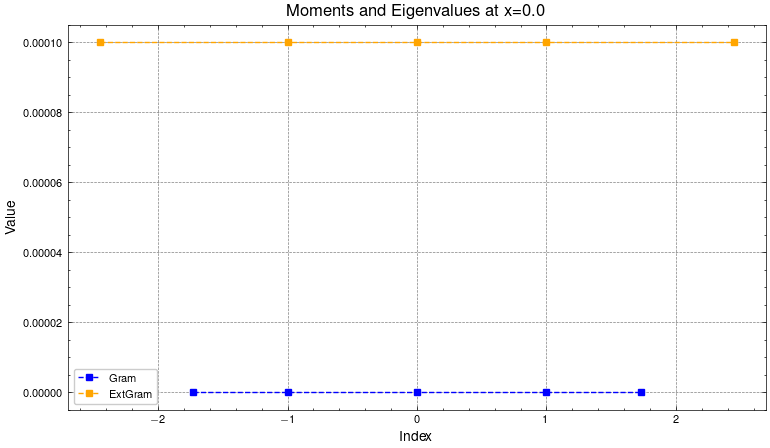

In [20]:
plt.subplots()
plt.plot(roots_subs_Gramian, [0]*len(roots_subs_Gramian), 's--', color='blue', label=f'Gram')
plt.plot(roots_subs_ExtendedGramian, [1e-4]*len(roots_subs_ExtendedGramian), 's--', color='orange', label=f'ExtGram')
plt.xlabel('Index')
plt.ylabel('Value')
plt.title(f'Moments and Eigenvalues at x={x_dest}')
plt.legend()
plt.show()

# Odd M

### Gramian closure for odd M

$P_{M+1}(c) = p_n(c) p_n(c)$

In [21]:
M = 3
n = int((M+1)/2)

M, n

Latex expression of characteristic polynomial: \frac{\left(- c^{2} \left(u_{0} u_{2} - u_{1}^{2}\right) - u_{2} \left(c u_{1} - u_{2}\right) + u_{3} \left(c u_{0} - u_{1}\right)\right)^{2}}{\left(u_{0} u_{2} - u_{1}^{2}\right)^{2}}


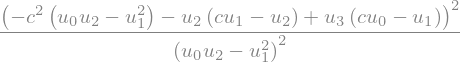

In [22]:
P_Gramian_odd = lambda c: (
    c**2 - Matrix(Matrix([1, c]).T * Matrix([[u0, u1], [u1, u2]]).inv() * Matrix([u2, u3]))[0]     # p_n(c)
) * (
    c**2 - Matrix(Matrix([1, c]).T * Matrix([[u0, u1], [u1, u2]]).inv() * Matrix([u2, u3]))[0]     # p_n(c)
)
P_Gramian_odd = simplify(P_Gramian_odd(c))

print(f'Latex expression of characteristic polynomial: {latex(P_Gramian_odd)}')
P_Gramian_odd

In [23]:
closure = "Gram"
source = "relaxation_source"
file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

x, u, _ = sol_final(file)

file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_eigenvalues.csv"
df = pd.read_csv(file)


x_dest = -2.0
x_idx = (np.abs(df['x_vector'] - x_dest)).argmin()
eigenvalue_string = df['eigenvalue'][x_idx]
eigenvalues_test_equilibrium = [float(val) for val in eigenvalue_string.strip('[]').split(',')]

In [24]:
moments_test_equilibrium = [
    7.0, 
    0.0, 
    7.0, 
    0.0, 
    21.0,
    0.0
]

subs_dict_equilibrium = {
    u0: moments_test_equilibrium[0],
    u1: moments_test_equilibrium[1],
    u2: moments_test_equilibrium[2],
    u3: moments_test_equilibrium[3],
    u4: moments_test_equilibrium[4],
    u5: moments_test_equilibrium[5]
}

P_Gramian_odd = P_Gramian_odd.subs(subs_dict_equilibrium)
P_Gramian_odd = simplify(P_Gramian_odd)

roots = solve(Eq(P_Gramian_odd, 0), c)
roots_subs = [simplify(root) for root in roots]

# Sort eigenvalues for easier comparison
# First assert that maximum imaginary eigenvalue part is small
max_imag_rouots = max([abs(re(root.subs(subs_dict_equilibrium).evalf().as_real_imag()[1])) for root in roots])
assert max_imag_rouots < 1e-10, f"Maximum imaginary part of eigenvalues is too large: {max_imag_rouots}"
roots_subs = [root.subs(subs_dict_equilibrium).evalf().as_real_imag()[0] for root in roots]
roots_subs.sort()
eigenvalues_test_equilibrium.sort()

print("Sorted Computed Eigenvalues:", roots_subs)
print("Sorted Test Eigenvalues:", eigenvalues_test_equilibrium)
# Check if computed eigenvalues match test eigenvalues
# err_rel, err_abs = [], []
# for r_computed, r_test in zip(roots_subs, eigenvalues_test_equilibrium):
#     err_rel.append(abs(r_computed - r_test) / abs(r_test))
#     err_abs.append(abs(r_computed - r_test))
# print("Relative Errors:", err_rel)
# print("Absolute Errors:", err_abs)

Sorted Computed Eigenvalues: [-1.00000000000000, 1.00000000000000]
Sorted Test Eigenvalues: [-0.9999999999999998, -0.9999999999999998, 1.0000000000000004, 1.0000000000000004]


### Extended Gramian closure for odd $M$ (Morin)

$P_{M+1}(c) = \left[\frac{p_n(c) p_n(c)}{\sigma_{n-1,n-1}} - \frac{\sigma_{n,n} p_{n-1}(c) p_{n-1}(c)}{\sigma_{n-1,n-1}^2}\right] - \frac{2}{n-1} \sum_{k=1}^{n-1} \left[\frac{p_k(c) p_k(c)}{\sigma{k-1,k-1}} - \frac{\sigma_{k,k} p_{k-1}(c) p_{k-1}(c)}{\sigma_{k-1,k-1}^2}\right] - \frac{2}{n-1}\sum_{l=0}^{n-1} \left[\left(\frac{\sigma_{n-1,n}}{\sigma_{n-1,n-1}}-\frac{\sigma_{n-2,n-1}}{\sigma_{n-2,n-2}}\right)-\left(\frac{\sigma_{l,l+1}}{\sigma_{l,l}} - \frac{\sigma_{l-1,l}}{\sigma_{l-1,l-1}}\right)\right] \left[\left(\frac{p_{n-1}(c) p_n(c)}{\sigma_{n-1,n-1}}-\frac{p_{n-2}(c) p_{n-1}(c)}{\sigma_{n-2,n-2}}\right) - \left(\frac{p_{l}(c) p_{l+1}(c)}{\sigma_{l,l}}-\frac{p_{l-1}(c) p_{l}(c)}{\sigma_{l-1,l-1}}\right)\right]$

### Chatti

In [25]:
# Orthogonal Polynomials (Hardcoded p_k)
p_m1 = sympify(0)
p_0 = sympify(1)
p_1 = simplify(c - u1/u0)
# p_2 uses G_1 and u_{2,3}
G1 = Matrix([[u0, u1], [u1, u2]])
u23 = Matrix([u2, u3])
c_vec1 = Matrix([1, c])
p_2 = simplify(c**2 - (c_vec1.T * G1.inv() * u23)[0])

# Variances sigma_kk (Hardcoded)
sigma_m1m1 = sympify(1)
sigma_00 = u0
sigma_11 = simplify(u2 - u1**2/u0)
# sigma_22 involves u4, which will be substituted by the closure later
sigma_22 = simplify(u4 - (u23.T * G1.inv() * u23)[0])

# Variances sigma_k,k+1 (Hardcoded)
sigma_m1_0 = sympify(0)
sigma_0_1 = u1
u34 = Matrix([u3, u4]) # u_vl for k=1, start_idx=k+1
u23_r = Matrix([u2, u3]) # u_vr for k=1, start_idx=k
sigma_1_2 = simplify(u3 - (Matrix([u2, u3]).T * G1.inv() * Matrix([u1, u2]))[0])
# Note: sigma_1_2 calculation depends on your specific u_vl/u_vr logic 
# sigma_1_2 = u3 - (u_vec_left^T * G_inv * u_vec_right)

In [26]:
# Recurrence Parameters alpha_k and beta_k (Explicit)
alpha_0 = sigma_0_1 / sigma_00
alpha_1 = (sigma_1_2 / sigma_11) - (sigma_0_1 / sigma_00)

beta_1 = sigma_11 / sigma_00

# Closure Bracket from Eq (67) for n=2
# beta_2 = 2/(n-1) * sum_{k=1}^1 beta_k + 1/(n-1) * sum_{l=0}^1 (alpha_1 - alpha_l)^2
bracket = (2/1) * (beta_1) + (1/1) * ((alpha_1 - alpha_0)**2 + (alpha_1 - alpha_1)**2)

# Moment Closure for u4 from Eq (68)
# u4 = Projection + sigma_{1,1} * bracket
proj_part = (u23.T * G1.inv() * u23)[0]
u4_closure = simplify(proj_part + sigma_11 * bracket)

# Re-define sigma_22 using the closed u4 value
sigma_22_closed = sigma_22.subs(u4, u4_closure)

Explicit Characteristic Polynomial for M=3 created.


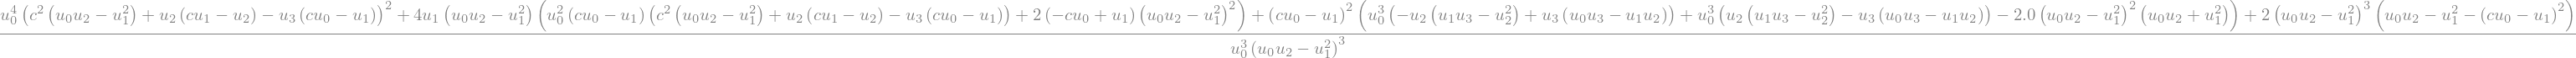

In [27]:
# Helper terms beta' and alpha' (Explicitly hardcoded for n=2)
# beta'_k = p_k^2/sigma_{k-1,k-1} - sigma_kk * p_{k-1}^2 / sigma_{k-1,k-1}^2
beta_p_1 = (p_1**2 / sigma_00) - (sigma_11 * p_0**2 / sigma_00**2)
beta_p_2 = (p_2**2 / sigma_11) - (sigma_22_closed * p_1**2 / sigma_11**2)

# alpha'_k = p_k * p_{k+1} / sigma_kk - p_{k-1} * p_k / sigma_{k-1,k-1}
# For l=0: alpha'_0 = p_0*p_1/sigma_00 - p_-1*p_0/sigma_-1-1
alpha_p_0 = (p_0 * p_1 / sigma_00)
# For l=1: alpha'_1 = p_1*p_2/sigma_11 - p_0*p_1/sigma_00
alpha_p_1 = (p_1 * p_2 / sigma_11) - (p_0 * p_1 / sigma_00)

# Term 1: beta'_2
term1 = beta_p_2

# Term 2: -2 * beta'_1
term2 = -2 * beta_p_1

# Term 3: -2 * sum_{l=0}^1 (alpha_1 - alpha_l) * (alpha'_1 - alpha'_l)
term3_0 = (alpha_1 - alpha_0) * (alpha_p_1 - alpha_p_0)
term3_1 = (alpha_1 - alpha_1) * (alpha_p_1 - alpha_p_1) # This is 0
term3 = -2 * (term3_0 + term3_1)

# Final Polynomial
P_EG_Odd_M3_Explicit = simplify(term1 + term2 + term3)

print("Explicit Characteristic Polynomial for M=3 created.")
P_EG_Odd_M3_Explicit

In [28]:
closure = "ExtGram"
source = "relaxation_source"
file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

x, u, _ = sol_final(file)

file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_eigenvalues.csv"
df = pd.read_csv(file)


x_dest = -2.0
x_idx = (np.abs(df['x_vector'] - x_dest)).argmin()
eigenvalue_string = df['eigenvalue'][x_idx]
eigenvalues_test_equilibrium = [float(val) for val in eigenvalue_string.strip('[]').split(',')]

In [29]:
P_EG_Odd_M3_Explicit = P_EG_Odd_M3_Explicit.subs(subs_dict_equilibrium)
P_EG_Odd_M3_Explicit = simplify(P_EG_Odd_M3_Explicit)

roots = solve(Eq(P_EG_Odd_M3_Explicit, 0), c)
roots_subs = [simplify(root) for root in roots]

# Sort eigenvalues for easier comparison
# First assert that maximum imaginary eigenvalue part is small
max_imag_rouots = max([abs(re(root.subs(subs_dict_equilibrium).evalf().as_real_imag()[1])) for root in roots])
assert max_imag_rouots < 1e-10, f"Maximum imaginary part of eigenvalues is too large: {max_imag_rouots}"
roots_subs = [root.subs(subs_dict_equilibrium).evalf().as_real_imag()[0] for root in roots]
roots_subs.sort()
eigenvalues_test_equilibrium.sort()

print("Sorted Computed Eigenvalues:", roots_subs)
print("Sorted Test Eigenvalues:", eigenvalues_test_equilibrium)

Sorted Computed Eigenvalues: [-2.33441421833898, -0.741963784302726, 0.741963784302726, 2.33441421833898]
Sorted Test Eigenvalues: [-2.334414218338978, -0.7419637843027254, 0.741963784302727, 2.334414218338979]


# Visualize all eigenvalues in equilibrium

In [30]:
moments_test_equilibrium = [
    7.0, 
    0.0, 
    7.0, 
    0.0, 
    21.0,
    0.0
]

subs_dict_equilibrium = {
    u0: moments_test_equilibrium[0],
    u1: moments_test_equilibrium[1],
    u2: moments_test_equilibrium[2],
    u3: moments_test_equilibrium[3],
    u4: moments_test_equilibrium[4],
    u5: moments_test_equilibrium[5]
}

######### Even #############
# Gramian
P_GramianEven_subs = simplify(P_GramianEven.subs(subs_dict_equilibrium))

roots_Gramian_Even = solve(Eq(P_GramianEven_subs, 0), c)
roots_subs_Gramian_Even = [simplify(root) for root in roots_Gramian_Even]

# Extended Gramian
P_ExtendedGramianEven_subs = simplify(P_ExtendedGramianEven.subs(subs_dict_equilibrium))

roots_ExtendedGramian_Even = solve(Eq(P_ExtendedGramianEven_subs, 0), c)
roots_subs_ExtendedGramian_Even = [simplify(root) for root in roots_ExtendedGramian_Even]


########## Odd #################
# Gramian
P_GramianOdd_subs = simplify(P_Gramian_odd.subs(subs_dict_equilibrium))

roots_Gramian_Odd = solve(Eq(P_GramianOdd_subs, 0), c)
roots_subs_Gramian_Odd = [simplify(root) for root in roots_Gramian_Odd]

# Extended Gramian
P_EG_Odd_M3_Explicit_subs = simplify(P_EG_Odd_M3_Explicit.subs(subs_dict_equilibrium))

roots_ExtendedGramian_Odd = solve(Eq(P_EG_Odd_M3_Explicit_subs, 0), c)
roots_ExtendedGramian_Odd = [simplify(root) for root in roots_ExtendedGramian_Odd]

In [32]:
subs_dict_equilibrium, roots_subs_ExtendedGramian_Even

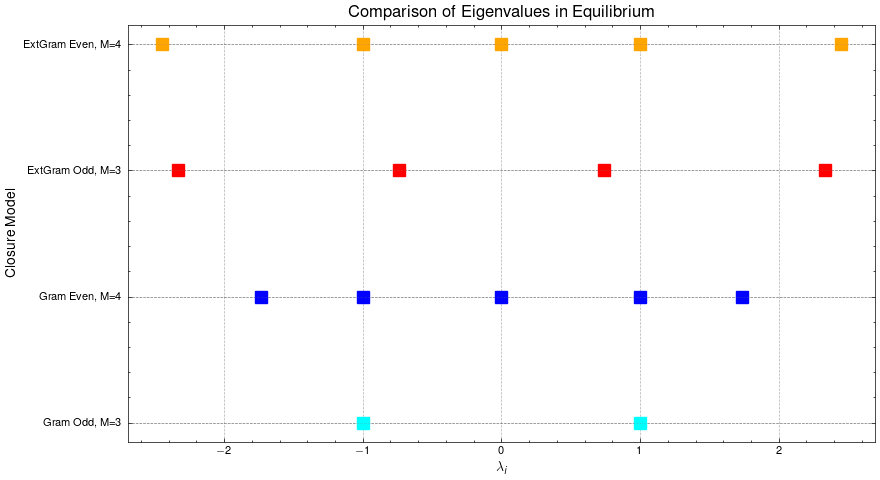

In [31]:
# Organize the data
models = [
    (roots_subs_Gramian_Odd, 'cyan', 'Gram Odd, M=3'),
    (roots_subs_Gramian_Even, 'blue', 'Gram Even, M=4'),
    (roots_ExtendedGramian_Odd, 'red', 'ExtGram Odd, M=3'),
    (roots_subs_ExtendedGramian_Even, 'orange', 'ExtGram Even, M=4')
]

plt.subplots()

for i, (roots, color, label) in enumerate(models):
    # Plot the eigenvalues as points at height 'i'
    plt.plot(roots, [i] * len(roots), 's', color=color, markersize=8, label=label)
    
    # Add a faint horizontal line to guide the eye for each category
    plt.axhline(i, color='gray', linestyle='--', linewidth=0.5, alpha=0.3)

# Set the y-ticks to match the index of the models and label them
plt.yticks(range(len(models)), [m[2] for m in models])

plt.xlabel('$\\lambda_i$')
plt.ylabel('Closure Model')
plt.title('Comparison of Eigenvalues in Equilibrium')
plt.grid(True, axis='x', alpha=0.3) # Grid only for x-axis to help read values

plt.tight_layout()
plt.show()